# 决策树算法原理与银行贷款分类实战


    
## 决策树提出的背景
- 提出决策树算法的时代，机器学习的概念已经提出
- 学习是智能行为的重要特征
- 学习方法分为两类
    - 一类是能够自我改进的自适应系统
    - 一类是基于结构化知识的学习方法
- 决策树是对专家系统学习过程的改进
    - 不再依赖于领域专家
    - 直接从数据中自动归纳总结规则

    
## 认识决策树
决策树思想的来源非常朴素，程序设计中的条件分支结构就是if-then结构，最早的决策树就是利用这类结构分割数据的一种分类学习方法

怎么理解这句话？通过一个对话例子：
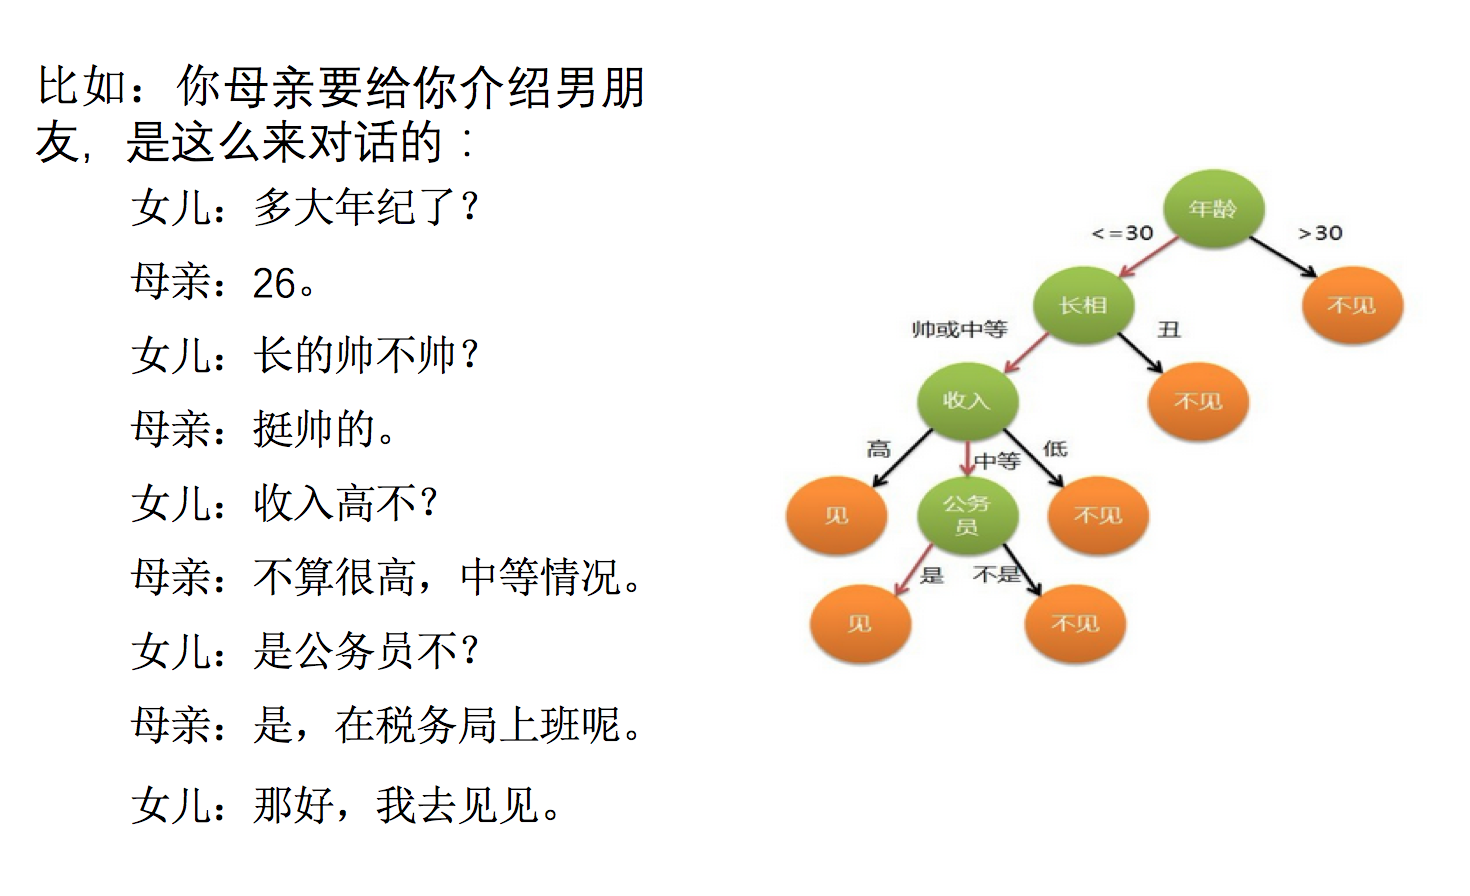

想一想这个女生为什么把年龄放在最上面判断！！！！！！！！！

## 决策树分类原理详解
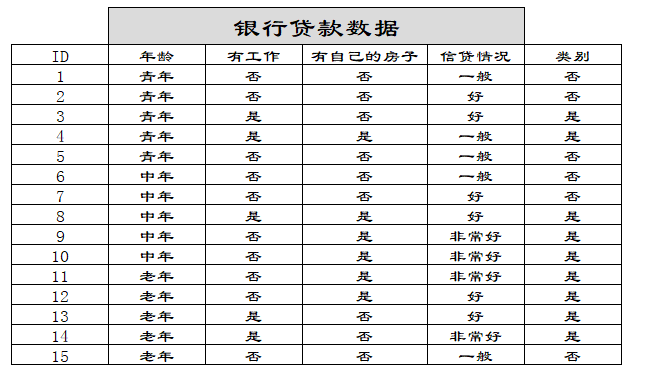

假设是二叉树的时候，决策树一般决策结果为如下图：
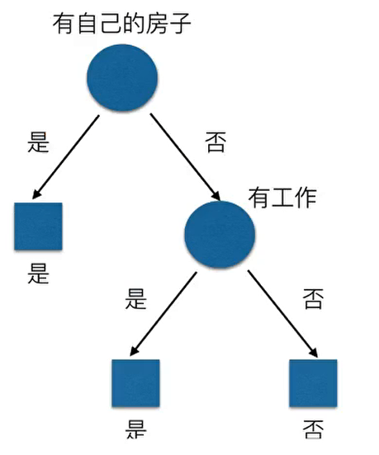

**在这里，为什么有自己的房子应该放在最开始的地方呢？**

## 决策树的优劣

- 分支条件的选择决定了树的优劣
- 简洁的树通常可以捕捉到最关键的分类条件
- 复杂的树极有可能发生过拟合

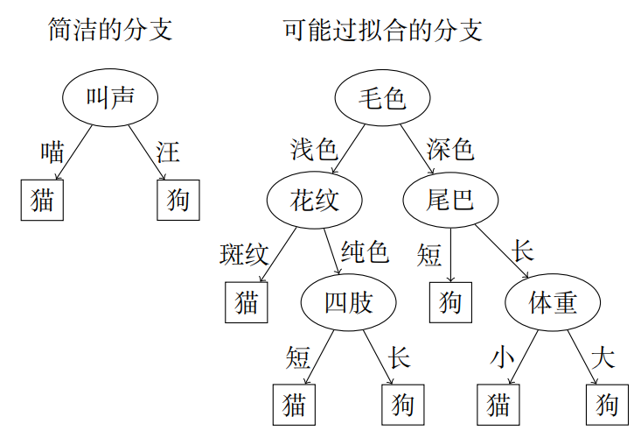

## 信息熵与信息增益
### 信息熵
来玩个猜测游戏，可以通过提问来猜测这32支球队那个是冠军。并且猜测错误付出代价。猜错一次给一块钱，告诉我是否猜对了，那么我需要掏多少钱才能知道谁是冠军？ （前提是：不知道任意球队的信息、历史比赛记录、实力等）
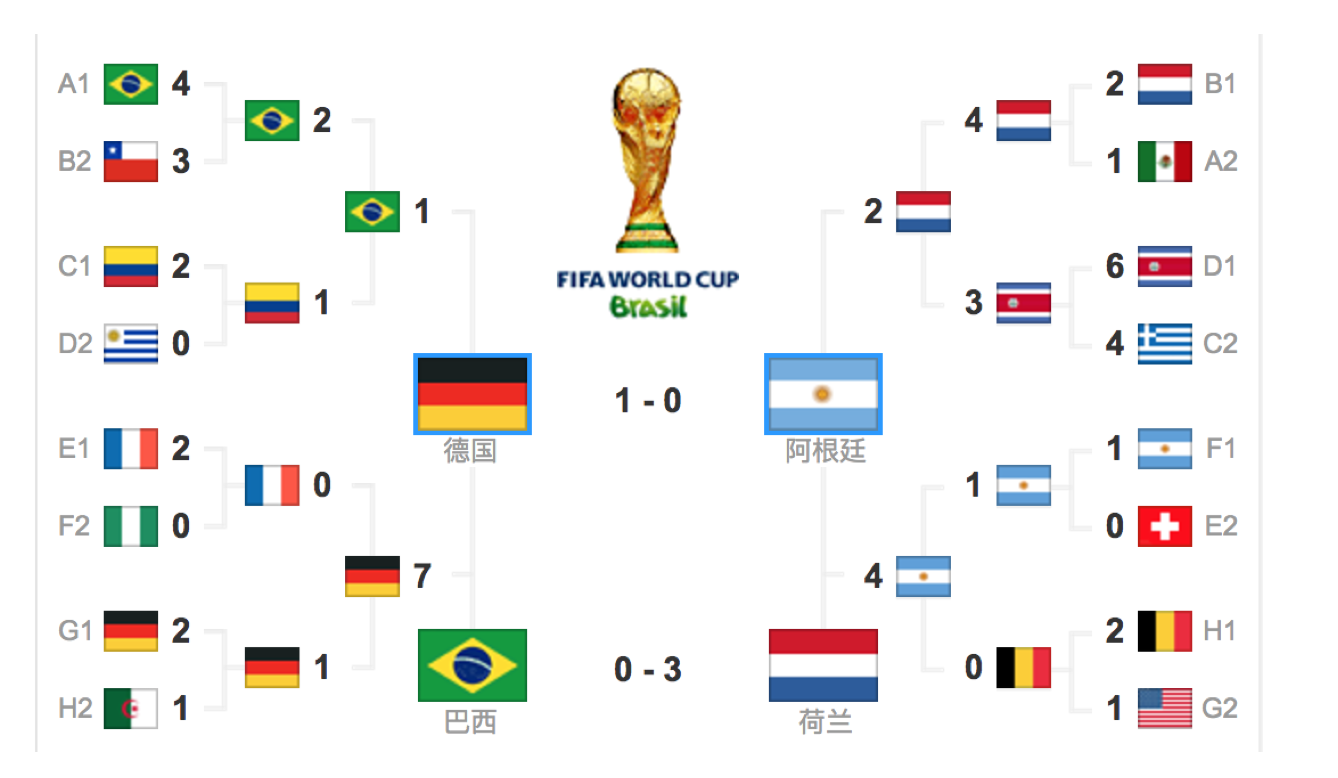

**为了使代价最小，可以使用二分法猜测：**

可以把球编上号，从1到32，然后提问：冠 军在1-16号吗？依次询问，只需要五次，就可以知道结果。
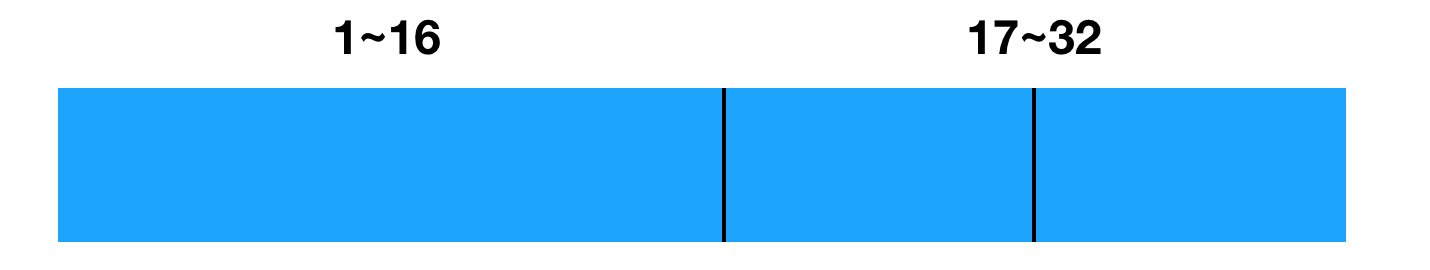
这5块钱就是得知问题结果的代价，我们可以不用钱去衡量这个代价了，香浓指出用比特：
- 32支球队，log32=5比特
- 64支球队，log64=6比特

#### 总结
- **信息和消除不确定性是相联系的**

当我们得到的额外信息（球队历史比赛情况等等）越多的话，那么我们猜测的代价越小（猜测的不确定性减小）

## 决策树的划分依据------信息增益

贷款案例，怎么去划分？可以利用当得知某个特征（比如是否有房子）之后，我们能够减少的不确定性大小。越大我们可以认为这个特征很重要。那怎么去衡量减少的不确定性大小呢？

- 信息增益是知道了某个条件（特征）后，事件的不确定性下降的程度。

## 决策树API
```python
class sklearn.tree.DecisionTreeClassifier(criterion='gini', max_depth=None,random_state=None)
```

- criterion:默认是’gini’系数，也可以选择信息增益的熵’entropy’
- max_depth:树的深度大小
- random_state:随机数种子

## 基于决策树实现鸢尾花分类
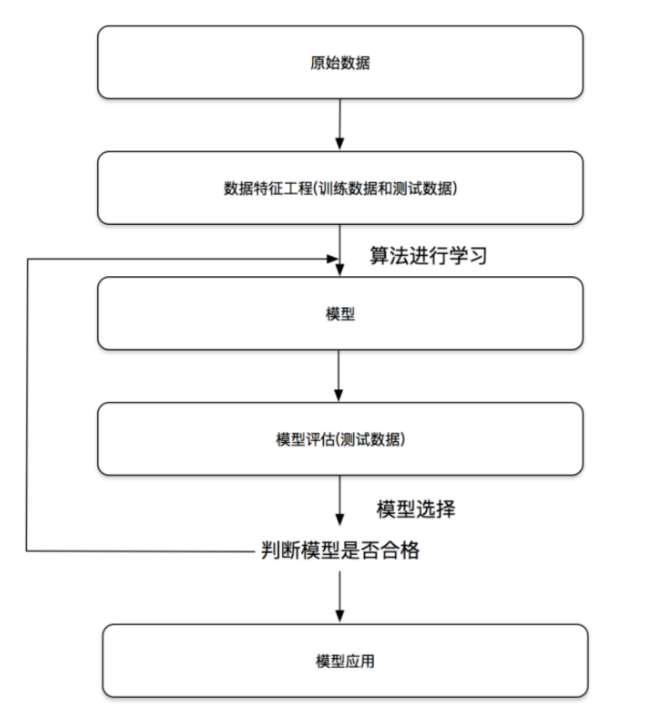


### 导入工具包
导入了必要的机器学习库：
- load_iris 用于加载经典的鸢尾花数据集
- train_test_split 用于将数据划分为训练集和测试集
- DecisionTreeClassifier 是决策树分类器
- plot_tree 用于可视化决策树
- matplotlib.pyplot 用于绘图

这些导入为后续的数据加载、模型训练和可视化奠定了基础。

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

### 加载数据

加载鸢尾花数据集，并将数据分为特征 X 和目标变量 y。然后，使用 train_test_split 函数将数据集划分为训练集和测试集，其中测试集占 20% 的比例。
这种划分是为了确保模型在训练时不会看到测试数据，以便能够公正地评估模型的性能。

In [2]:
# 加载数据集
iris = load_iris()

X = iris['data']
y = iris['target']

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### 决策树的创建与训练
创建了一个决策树分类器 tree，并设置了 max_depth=5 以限制树的深度，防止过拟合，同时 random_state=42 确保结果的可重复性。然后，使用 fit 方法在训练数据 X_train 和 y_train 上训练模型。通过训练，模型学习如何根据输入特征对鸢尾花进行分类。

In [3]:
# 构建决策树算法
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

### 决策树模型预测

使用训练好的决策树模型 tree 对测试集 X_test 进行预测，预测结果是一个数组，包含模型对测试集中每个样本的类别预测。

In [4]:
a = tree.predict(X_test)
a

array([1, 0, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 0, 2, 0, 0, 2, 0, 0, 0, 1, 1,
       1, 2, 0, 2, 1, 0, 2, 1])

### 模型准确率
计算决策树模型在测试集上的准确率。tree.score(X_test, y_test) 方法比较了模型对测试集 X_test 的预测结果与真实标签 y_test，然后计算正确预测的比例，即准确率。这个准确率反映了模型在未见过的数据上的表现。

In [5]:
b = tree.score(X_test, y_test) # （准确样本数）/（总数）
b

0.9666666666666667

### 决策树可视化
使用 plot_tree 函数绘制了决策树 tree 的可视化图形。feature_names 参数指定了特征名称，class_names 参数指定了类别名称，filled=True 用于根据类别填充颜色，rounded=True 用于绘制圆角矩形，使树结构更加美观和易读。

[Text(358.7142857142857, 398.64, 'petal length (cm) <= 2.5\ngini = 0.666\nsamples = 120\nvalue = [39, 42, 39]\nclass = 1'),
 Text(310.8857142857143, 326.15999999999997, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]\nclass = 0'),
 Text(406.54285714285714, 326.15999999999997, 'petal width (cm) <= 1.75\ngini = 0.499\nsamples = 81\nvalue = [0, 42, 39]\nclass = 1'),
 Text(239.14285714285714, 253.67999999999998, 'petal length (cm) <= 5.05\ngini = 0.162\nsamples = 45\nvalue = [0, 41, 4]\nclass = 1'),
 Text(143.4857142857143, 181.2, 'sepal length (cm) <= 4.95\ngini = 0.048\nsamples = 41\nvalue = [0, 40, 1]\nclass = 1'),
 Text(95.65714285714286, 108.71999999999997, 'sepal width (cm) <= 2.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]\nclass = 1'),
 Text(47.82857142857143, 36.23999999999995, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]\nclass = 1'),
 Text(143.4857142857143, 36.23999999999995, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = 2'),
 Text(191.31428571428572, 108.71999999999997, '

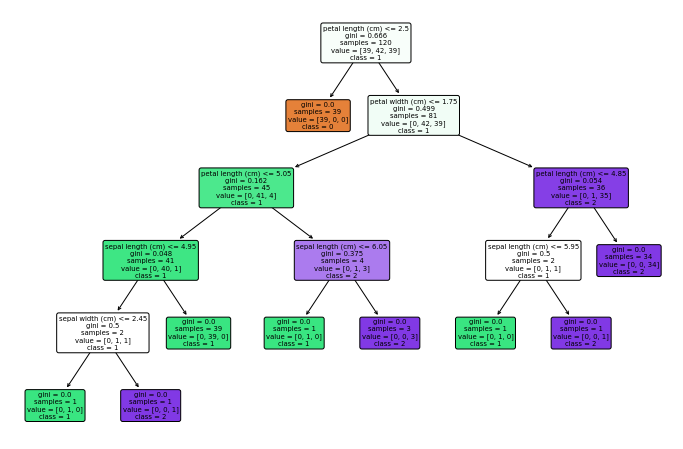

In [6]:
plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], class_names=['0', '1', '2'], filled=True, rounded=True)

## 决策树总结

- 优点：
    - 简单的理解和解释，树木可以可视化；
    - 需要很少的数据准备，其他技术通常需要归一化。
- 缺点：
    - 过拟合
- 改进：
    - 随机森林


In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder  # 编码器
import matplotlib.pyplot as plt

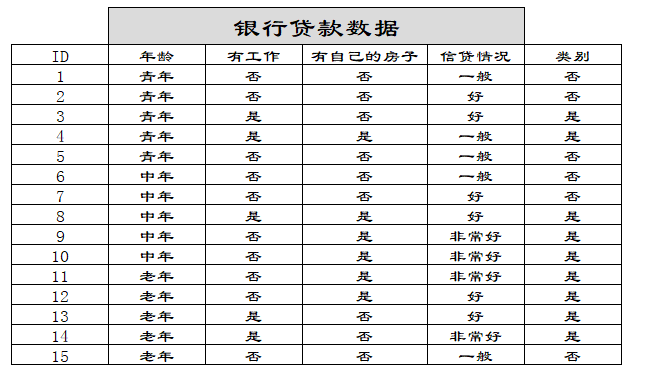

In [2]:
# 创建数据
data = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    '年龄': ['青年', '青年', '青年', '青年', '青年', '中年', '中年', '中年', '中年', '中年', '老年', '老年', '老年', '老年', '老年'],
    '有工作': ['否', '否', '是', '是', '否', '否', '否', '是', '否', '否', '否', '否', '是', '是', '否'],
    '有自己的房子': ['否', '否', '否', '是', '否', '否', '否', '是', '是', '是', '是', '是', '否', '否', '否'],
    '信贷情况': ['一般', '好', '好', '一般', '一般', '一般', '好', '好', '非常好', '非常好', '非常好', '好', '好', '非常好', '一般'],
    '类别': ['否', '否', '是', '是', '否', '否', '否', '是', '是', '是', '是', '是', '是', '是', '否']
}

df = pd.DataFrame(data)

# 2. 将分类特征转换为数值特征 - 确保对所有列使用相同的编码器
le_age = LabelEncoder() # 实例化编码器
le_work = LabelEncoder()
le_house = LabelEncoder()
le_credit = LabelEncoder()
le_target = LabelEncoder()
 
df['年龄'] = le_age.fit_transform(df['年龄'])  # 开始转码
df['有工作'] = le_work.fit_transform(df['有工作'])
df['有自己的房子'] = le_house.fit_transform(df['有自己的房子'])
df['信贷情况'] = le_credit.fit_transform(df['信贷情况'])
df['类别'] = le_target.fit_transform(df['类别'])
print(df)
 
# 3. 分离特征和目标变量
X = df.drop(['ID', '类别'], axis=1)
y = df['类别']

    ID  年龄  有工作  有自己的房子  信贷情况  类别
0    1   2    0       0     0   0
1    2   2    0       0     1   0
2    3   2    1       0     1   1
3    4   2    1       1     0   1
4    5   2    0       0     0   0
5    6   0    0       0     0   0
6    7   0    0       0     1   0
7    8   0    1       1     1   1
8    9   0    0       1     2   1
9   10   0    0       1     2   1
10  11   1    0       1     2   1
11  12   1    0       1     1   1
12  13   1    1       0     1   1
13  14   1    1       0     2   1
14  15   1    0       0     0   0


In [3]:
# 数据集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  # 数据划分
print(X_train)

    年龄  有工作  有自己的房子  信贷情况
8    0    0       1     2
2    2    1       0     1
1    2    0       0     1
14   1    0       0     0
4    2    0       0     0
7    0    1       1     1
10   1    0       1     2
12   1    1       0     1
3    2    1       1     0
6    0    0       0     1


### 算法创建与训练

In [4]:
# 创建决策树分类器
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)  # 算法创建

# 训练模型
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [5]:
# 预测测试集
y_pred = dt.predict(X_test)  # 考试
print(y_pred) # 预测答案

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)  
print(f"模型准确率: {accuracy:.2f}")

# 分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred))

[1 1 0 1 0]
模型准确率: 1.00

分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5




决策树规则:
|--- 有自己的房子 <= 0.50
|   |--- 有工作 <= 0.50
|   |   |--- class: 0
|   |--- 有工作 >  0.50
|   |   |--- class: 1
|--- 有自己的房子 >  0.50
|   |--- class: 1



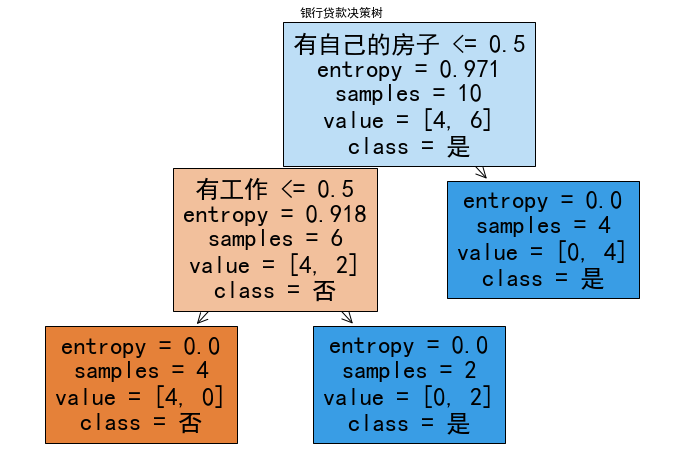

In [6]:
# 文本形式显示决策树

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
tree_rules = export_text(dt, feature_names=list(X.columns))
print("\n决策树规则:")
print(tree_rules)

# 图形化显示决策树
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=list(X.columns), class_names=['否', '是'], filled=True)
plt.title("银行贷款决策树")
plt.show()

In [7]:
# 8. 示例预测 - 确保使用训练时相同的编码器
sample = pd.DataFrame({
    '年龄': [le_age.transform(['中年'])[0]],  # 使用训练时的编码器
    '有工作': [le_work.transform(['是'])[0]],
    '有自己的房子': [le_house.transform(['否'])[0]],
    '信贷情况': [le_credit.transform(['一般'])[0]]
})
 
prediction = dt.predict(sample)
print(f"\n预测结果: {'批准' if prediction[0] == 1 else '不批准'}")


预测结果: 批准
